# Adversarial Training for Flower Classification with ResNet50

This notebook demonstrates how to perform **Adversarial Training** using the formula:

$$\tilde{J}(\theta, x, y) = \alpha J(\theta, x, y) + (1 - \alpha) J(\theta, x + \epsilon \text{ sign}(\nabla_x J(\theta, x, y)))$$

This approach makes the model more robust by training on a weighted mix of clean and adversarial examples.

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version: {tf.__version__}")

2026-06-16 16:19:05.061227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781626745.250284      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781626745.306151      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781626745.749465      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781626745.749517      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781626745.749523      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## 1. Data Preparation

Split

In [2]:
DATASET_PATH = '/kaggle/input/datasets/haidangg/flowerdataset/flower_photos'
TEST_SET_PATH = '/kaggle/input/datasets/haidangg/flowerdataset/flower_photos_test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_SET_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 3090 files belonging to 5 classes.
Using 2472 files for training.


I0000 00:00:1781626772.452750      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781626772.458810      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 3090 files belonging to 5 classes.
Using 618 files for validation.
Found 580 files belonging to 5 classes.


## 2. Model Definition

In [3]:
from tensorflow.keras.applications import ResNet50

# Khởi tạo mô hình ResNet50 pre-trained từ tf.keras.applications
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Cho phép huấn luyện (fine-tune) toàn bộ mô hình ResNet50
base_model.trainable = True 

# Xây dựng mô hình Sequential
model = models.Sequential([
    # Lớp Lambda thực hiện preprocessing của ResNet50 (nhân 255 và gọi preprocess_input)
    # Giúp mô hình tự động xử lý đầu vào từ khoảng [0, 1] sang định dạng ResNet50 yêu cầu
    layers.Lambda(
        lambda x: tf.keras.applications.resnet50.preprocess_input(x * 255.0),
        input_shape=(224, 224, 3),
        name="resnet50_preprocessing"
    ),
    base_model,
    layers.GlobalAveragePooling2D(name="global_average_pooling"),
    layers.Dropout(0.5, name="dropout_robustness"),
    layers.Dense(num_classes, activation='softmax', name="classifier_output")
])

# Biên dịch mô hình với learning rate thấp để bảo toàn các weight tốt của ResNet50
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50_preprocessing (La  (None, 224, 224, 3)       0         
 mbda)                                                           
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling (Gl  (None, 2048)              0         
 obalAveragePooling2D)                                           
                                                                 
 dropout_robustness (Dropou  (None, 2048)              0         
 t)                                                              
                                                                 
 classifier_output (Dense)   (None, 5)                 10

## 3. Adversarial Training Wrapper

Here we implement the custom training step that follows the formula.

In [4]:
class AdversarialModel(models.Model):
    def __init__(self, base_model, epsilon=0.01, alpha=0.5, pgd_alpha=0.0025, pgd_steps=10):
        super(AdversarialModel, self).__init__()
        self.base_model = base_model
        
        # Tham số kết hợp Loss
        self.alpha = alpha
        
        # Tham số của PGD
        self.epsilon = epsilon
        self.pgd_alpha = pgd_alpha
        self.pgd_steps = pgd_steps
        
        self.loss_object = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
        
        # Khởi tạo các bộ đếm Metrics chuyên biệt
        self.loss_total_metric = tf.keras.metrics.Mean(name="loss")
        self.acc_clean_metric = tf.keras.metrics.CategoricalAccuracy(name="std_acc")
        self.acc_adv_metric = tf.keras.metrics.CategoricalAccuracy(name="robust_acc")
        self.asr_metric = tf.keras.metrics.Mean(name="asr") # Attack Success Rate

    @property
    def metrics(self):
        return [self.loss_total_metric, self.acc_clean_metric, self.acc_adv_metric, self.asr_metric]

    def _calculate_asr(self, y_true, pred_clean, pred_adv):
        true_labels = tf.argmax(y_true, axis=1)
        clean_labels = tf.argmax(pred_clean, axis=1)
        adv_labels = tf.argmax(pred_adv, axis=1)
        
        clean_correct = tf.equal(clean_labels, true_labels)
        adv_incorrect = tf.not_equal(adv_labels, true_labels)
        successful_attacks = tf.logical_and(clean_correct, adv_incorrect)
        
        num_clean_correct = tf.reduce_sum(tf.cast(clean_correct, tf.float32))
        num_successful_attacks = tf.reduce_sum(tf.cast(successful_attacks, tf.float32))
        
        asr = tf.cond(num_clean_correct > 0,
                      lambda: num_successful_attacks / num_clean_correct,
                      lambda: 0.0)
        return asr

    def _generate_pgd_adversary(self, x, y):
        # 1. Khởi tạo ngẫu nhiên (Random Initialization) quanh điểm gốc x
        noise = tf.random.uniform(tf.shape(x), minval=-self.epsilon, maxval=self.epsilon)
        x_adv = x + noise
        x_adv = tf.clip_by_value(x_adv, 0.0, 1.0) # projection
        
        # 2. Vòng lặp tối ưu PGD
        for _ in range(self.pgd_steps):
            with tf.GradientTape() as tape_adv:
                tape_adv.watch(x_adv)
                prediction = self.base_model(x_adv, training=False)
                loss = self.loss_object(y, prediction)
                
            # Tính gradient của loss theo ảnh nhiễu hiện tại
            gradient = tape_adv.gradient(loss, x_adv)
            signed_grad = tf.sign(gradient)
            
            # Tiến 1 bước nhỏ pgd_alpha
            x_adv = x_adv + self.pgd_alpha * signed_grad
            
            # Phép chiếu (Projection) 1: Kẹp vào vùng epsilon của ảnh gốc x
            x_adv = tf.clip_by_value(x_adv, x - self.epsilon, x + self.epsilon)
            
            # Phép chiếu (Projection) 2: Kẹp vào không gian màu hợp lệ [0, 1]
            x_adv = tf.clip_by_value(x_adv, 0.0, 1.0)
            
        # Chỗ này là bước tạo ảnh nhiễu nên không tham gia vào backpropagation
        # stop để cấm backpropagation dò lại các phép tính
        return tf.stop_gradient(x_adv)

    def train_step(self, data):
        x, y = data
        
        # 1. Chế tạo ảnh nhiễu PGD
        x_adv = self._generate_pgd_adversary(x, y)
        
        # 2. Dự đoán và Tính Loss tổng
        with tf.GradientTape() as tape:
            pred_clean = self.base_model(x, training=True)
            pred_adv = self.base_model(x_adv, training=True)
            
            loss_clean = self.loss_object(y, pred_clean)
            loss_adv = self.loss_object(y, pred_adv)
            
            total_loss = self.alpha * loss_clean + (1.0 - self.alpha) * loss_adv
            
        # 3. Cập nhật trọng số Model
        gradients = tape.gradient(total_loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.base_model.trainable_variables))
        
        # 4. Cập nhật các thông số hiển thị
        asr = self._calculate_asr(y, pred_clean, pred_adv)
        
        self.loss_total_metric.update_state(total_loss)
        self.acc_clean_metric.update_state(y, pred_clean)
        self.acc_adv_metric.update_state(y, pred_adv)
        self.asr_metric.update_state(asr)
        
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        
        # 1. Chế tạo ảnh nhiễu PGD
        x_adv = self._generate_pgd_adversary(x, y)
        
        # 2. Dự đoán trên tập Validation (training=False)
        pred_clean = self.base_model(x, training=False)
        pred_adv = self.base_model(x_adv, training=False)
        
        loss_clean = self.loss_object(y, pred_clean)
        loss_adv = self.loss_object(y, pred_adv)
        total_loss = self.alpha * loss_clean + (1.0 - self.alpha) * loss_adv
        
        # 3. Cập nhật các thông số hiển thị cho tập Validation
        asr = self._calculate_asr(y, pred_clean, pred_adv)
        
        self.loss_total_metric.update_state(total_loss)
        self.acc_clean_metric.update_state(y, pred_clean)
        self.acc_adv_metric.update_state(y, pred_adv)
        self.asr_metric.update_state(asr)
        
        return {m.name: m.result() for m in self.metrics}

    def call(self, x):
        return self.base_model(x)

# Khởi tạo model với PGD steps = 10
adv_training_model = AdversarialModel(
    base_model=model, # 'model' ResNet50
    epsilon=0.01, 
    alpha=0.3, 
    pgd_alpha=0.0025,
    pgd_steps=10
)

adv_training_model.compile(optimizer=Adam(learning_rate=1e-5))

## 4. Training

In [5]:
# Dừng sớm nếu val_loss không giảm sau 7 epochs
early_stop = EarlyStopping(monitor='val_robust_acc', mode='max', patience=7, restore_best_weights=True)

# Giảm tốc độ học nếu mô hình bị chững lại
reduce_lr = ReduceLROnPlateau(monitor='val_robust_acc', mode='max', factor=0.5, patience=5)

EPOCHS = 200
history = adv_training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/200


I0000 00:00:1781626823.071804      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781626830.786426      75 service.cc:152] XLA service 0x798bacee2330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781626830.786478      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781626830.786484      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781626831.026939      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 [==============================] - 389s 4s/step - loss: 3.9016 - std_acc: 0.4239 - robust_acc: 0.0481 - asr: 0.9171 - val_loss: 5.6436 - val_std_acc: 0.7832 - val_robust_acc: 0.1294 - val_asr: 0.8323 - lr: 1.0000e-05
Epoch 2/200
78/78 [==============================] - 293s 4s/step - loss: 2.5280 - std_acc: 0.6521 - robust_acc: 0.2043 - asr: 0.7128 - val_loss: 3.6047 - val_std_acc: 0.7848 - val_robust_acc: 0.1602 - val_asr: 0.7945 - lr: 1.0000e-05
Epoch 3/200
78/78 [==============================] - 293s 4s/step - loss: 1.8091 - std_acc: 0.6481 - robust_acc: 0.1234 - asr: 0.8208 - val_loss: 2.2464 - val_std_acc: 0.7621 - val_robust_acc: 0.0502 - val_asr: 0.9371 - lr: 1.0000e-05
Epoch 4/200
78/78 [==============================] - 292s 4s/step - loss: 1.7060 - std_acc: 0.7059 - robust_acc: 0.1137 - asr: 0.8498 - val_loss: 1.9148 - val_std_acc: 0.7508 - val_robust_acc: 0.0615 - val_asr: 0.9212 - lr: 1.0000e-05
Epoch 5/200
78/78 [==============================] - 292s 4s/step - loss

## 5. Training Monitoring

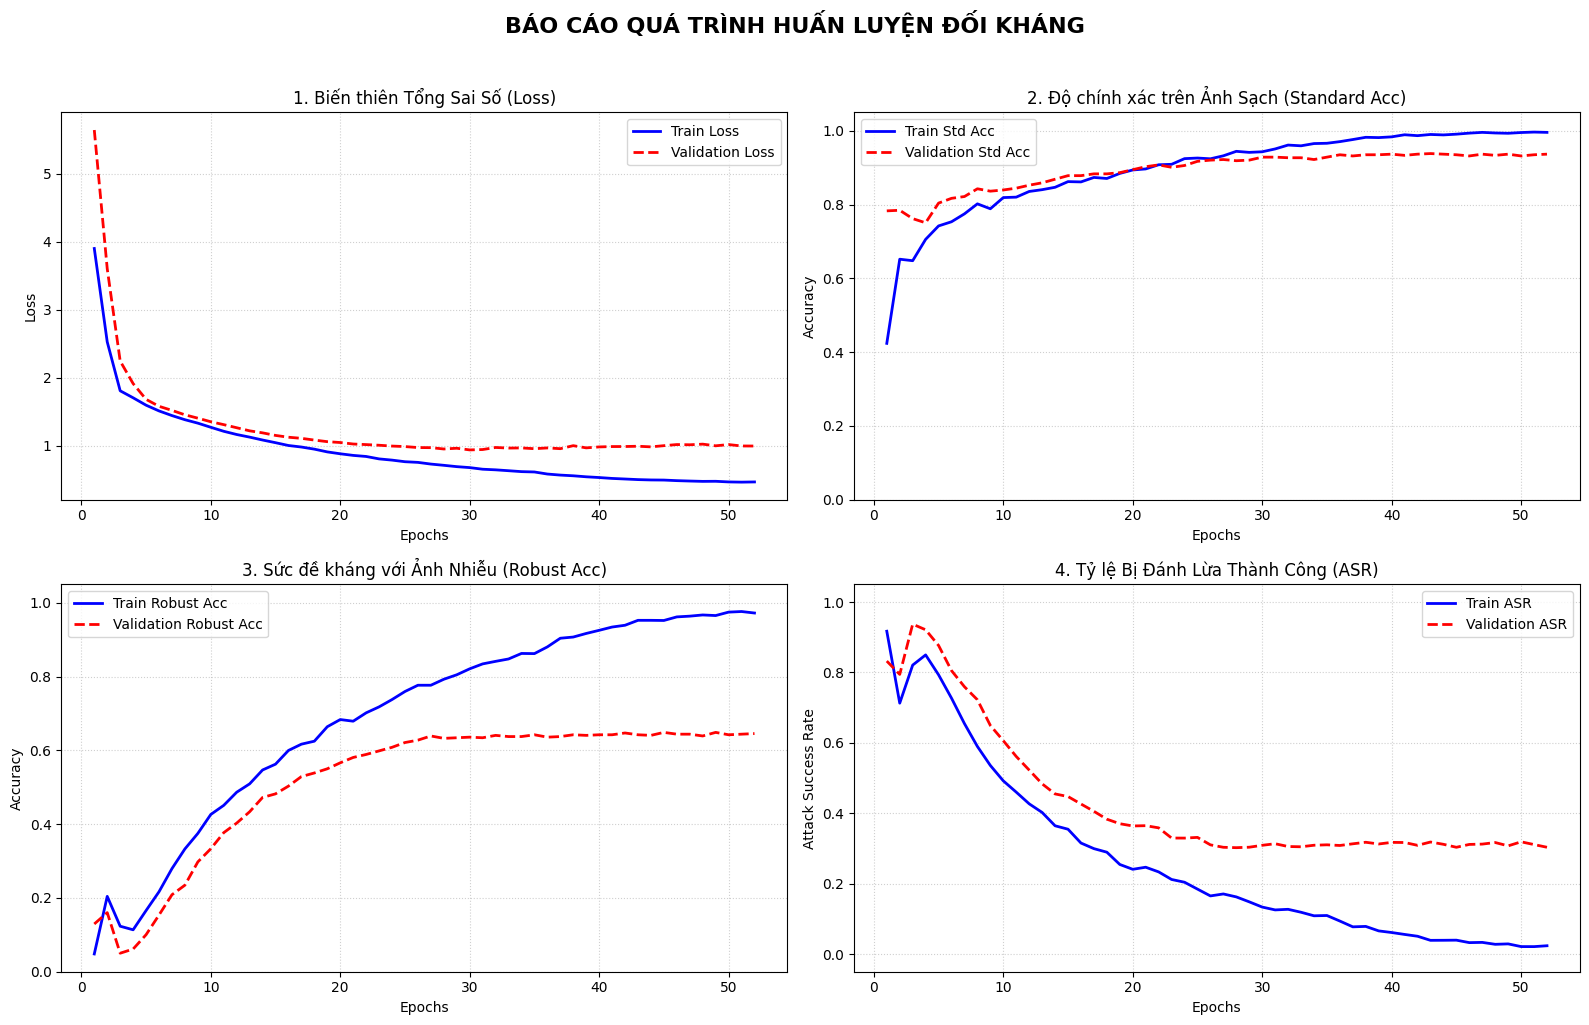

In [6]:
def plot_training_history(history):
    # Lấy dictionary chứa lịch sử các thông số
    h = history.history
    
    # Lấy số lượng epoch thực tế (đề phòng EarlyStopping dừng sớm)
    epochs = range(1, len(h['loss']) + 1)
    
    # Tạo một khung hình lớn chứa 4 biểu đồ nhỏ (2 hàng, 2 cột)
    plt.figure(figsize=(16, 10))
    plt.suptitle('BÁO CÁO QUÁ TRÌNH HUẤN LUYỆN ĐỐI KHÁNG', fontsize=16, fontweight='bold', y=1.02)

    # ---------------------------------------------
    # BIỂU ĐỒ 1: TỔNG SAI SỐ (TOTAL LOSS) - CÀNG THẤP CÀNG TỐT
    # ---------------------------------------------
    plt.subplot(2, 2, 1)
    plt.plot(epochs, h['loss'], 'b-', linewidth=2, label='Train Loss')
    if 'val_loss' in h:
        plt.plot(epochs, h['val_loss'], 'r--', linewidth=2, label='Validation Loss')
    plt.title('1. Biến thiên Tổng Sai Số (Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # ---------------------------------------------
    # BIỂU ĐỒ 2: STANDARD ACCURACY - CÀNG CAO CÀNG TỐT
    # ---------------------------------------------
    plt.subplot(2, 2, 2)
    plt.plot(epochs, h['std_acc'], 'b-', linewidth=2, label='Train Std Acc')
    if 'val_std_acc' in h:
        plt.plot(epochs, h['val_std_acc'], 'r--', linewidth=2, label='Validation Std Acc')
    plt.title('2. Độ chính xác trên Ảnh Sạch (Standard Acc)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1.05])
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # ---------------------------------------------
    # BIỂU ĐỒ 3: ROBUST ACCURACY - CÀNG CAO CÀNG TỐT
    # ---------------------------------------------
    plt.subplot(2, 2, 3)
    plt.plot(epochs, h['robust_acc'], 'b-', linewidth=2, label='Train Robust Acc')
    if 'val_robust_acc' in h:
        plt.plot(epochs, h['val_robust_acc'], 'r--', linewidth=2, label='Validation Robust Acc')
    plt.title('3. Sức đề kháng với Ảnh Nhiễu (Robust Acc)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1.05])
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # ---------------------------------------------
    # BIỂU ĐỒ 4: ATTACK SUCCESS RATE (ASR) - CÀNG THẤP CÀNG TỐT
    # ---------------------------------------------
    plt.subplot(2, 2, 4)
    plt.plot(epochs, h['asr'], 'b-', linewidth=2, label='Train ASR')
    if 'val_asr' in h:
        plt.plot(epochs, h['val_asr'], 'r--', linewidth=2, label='Validation ASR')
    plt.title('4. Tỷ lệ Bị Đánh Lừa Thành Công (ASR)')
    plt.xlabel('Epochs')
    plt.ylabel('Attack Success Rate')
    plt.ylim([-0.05, 1.05])
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # Tối ưu khoảng cách giữa các biểu đồ
    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ bằng cách truyền biến history vào
plot_training_history(history)

## 6. Evaluation


 BÁO CÁO ĐÁNH GIÁ ĐỘ BỀN VỮNG (ROBUSTNESS REPORT)
 Biên độ nhiễu (Epsilon)   : 0.01
 1. Standard Accuracy      : 92.24%  (Độ chính xác trên ảnh sạch)
 2. Robust Accuracy        : 77.24%  (Độ chính xác trên ảnh nhiễu)
 3. Attack Success Rate    : 16.26%  (Tỷ lệ đánh lừa mô hình thành công)

 Hiển thị 3 ví dụ bị tấn công thành công:


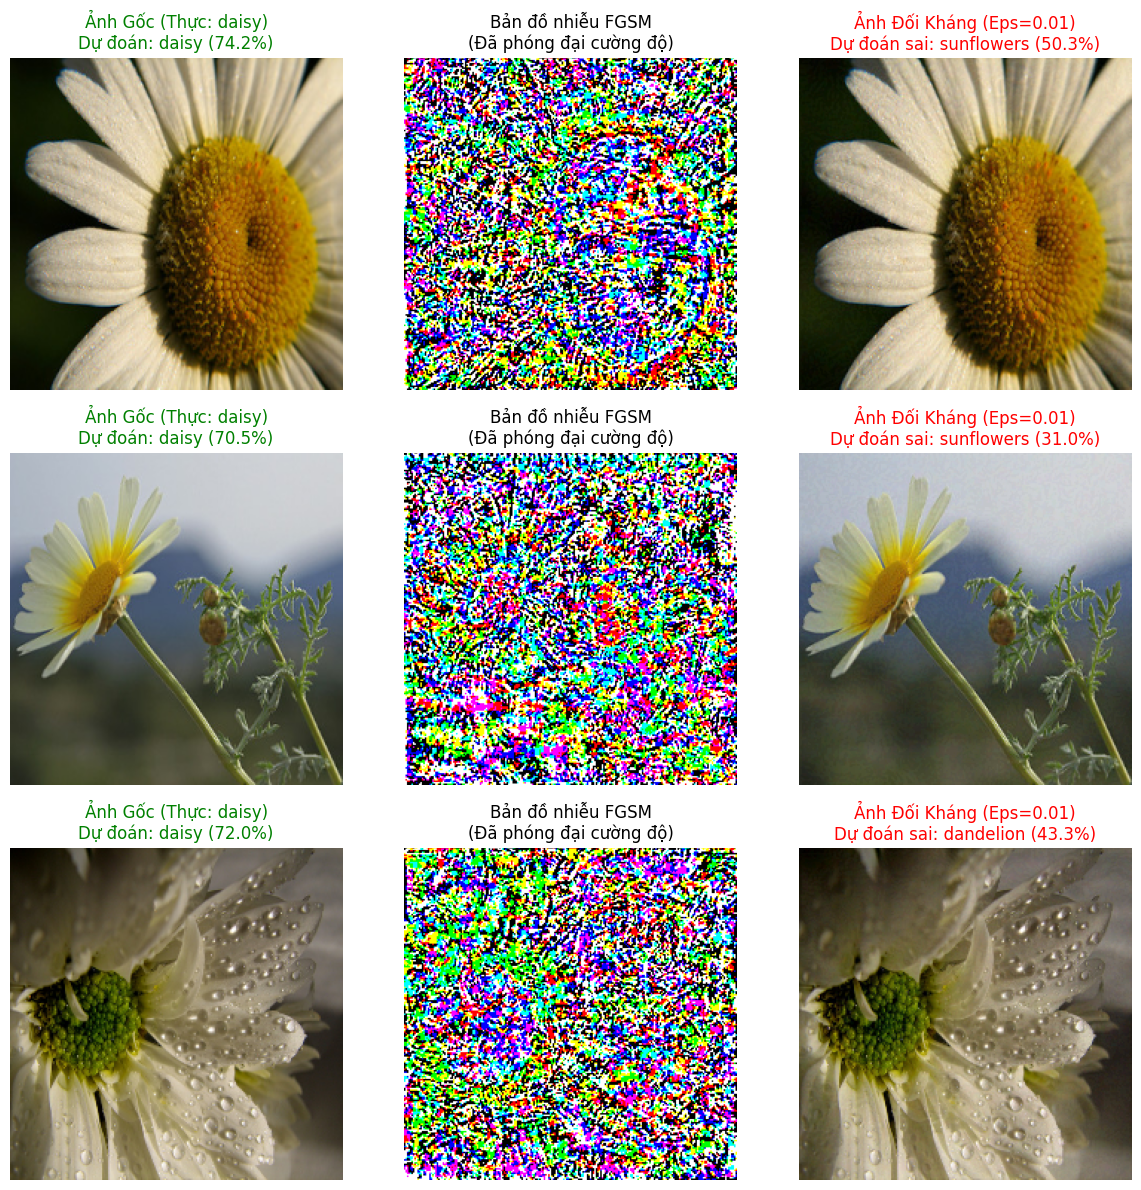

In [7]:
def evaluate_robustness(model, dataset, class_names, epsilon=0.01, num_visualize=3):
    """
    Hàm đánh giá độ bền vững của mô hình và trực quan hóa kết quả.
    
    Args:
        model: Mô hình Keras cần đánh giá.
        dataset: Tập dữ liệu (VD: val_ds).
        class_names: Danh sách tên các nhãn (VD: ['Hoa cúc', 'Hoa hồng', ...]).
        epsilon: Biên độ nhiễu.
        num_visualize: Số lượng ví dụ muốn hiển thị ra biểu đồ.
    """
    clean_acc = tf.keras.metrics.CategoricalAccuracy()
    adv_acc = tf.keras.metrics.CategoricalAccuracy()
    
    total_correct_clean = 0
    successful_attacks = 0
    
    # Biến lưu trữ dữ liệu để vẽ biểu đồ
    viz_clean_imgs, viz_adv_imgs, viz_noises = [], [], []
    viz_clean_preds, viz_adv_preds, viz_true_labels = [], [], []

    for x, y in dataset:
        # Nhớ để training=False để Dropout/BatchNorm không hoạt động sai
        clean_preds = model(x, training=False) 
        clean_acc.update_state(y, clean_preds)
        
        with tf.GradientTape() as tape:
            tape.watch(x)
            preds = model(x, training=False)
            loss = tf.keras.losses.CategoricalCrossentropy()(y, preds)
        
        grad = tape.gradient(loss, x)
        signed_grad = tf.sign(grad)
        x_adv = x + epsilon * signed_grad
        x_adv = tf.clip_by_value(x_adv, 0, 1)
        
        adv_preds = model(x_adv, training=False)
        adv_acc.update_state(y, adv_preds)
        
        # --- TÍNH TOÁN ATTACK SUCCESS RATE (ASR) ---
        true_labels = tf.argmax(y, axis=1)
        clean_labels = tf.argmax(clean_preds, axis=1)
        adv_labels = tf.argmax(adv_preds, axis=1)
        
        clean_correct = tf.equal(clean_labels, true_labels)
        adv_incorrect = tf.not_equal(adv_labels, true_labels)
        
        total_correct_clean += tf.reduce_sum(tf.cast(clean_correct, tf.int32)).numpy()
        successful_attacks += tf.reduce_sum(tf.cast(tf.logical_and(clean_correct, adv_incorrect), tf.int32)).numpy()
        
        # --- LƯU LẠI VÍ DỤ ĐỂ VẼ BIỂU ĐỒ ---
        if len(viz_clean_imgs) < num_visualize:
            for i in range(len(x)):
                if len(viz_clean_imgs) >= num_visualize:
                    break
                # Chỉ hiển thị những ảnh mà Tấn công thành công (Lúc đầu đoán đúng, sau bị lừa đoán sai)
                if clean_correct[i] and adv_incorrect[i]:
                    viz_clean_imgs.append(x[i].numpy())
                    viz_adv_imgs.append(x_adv[i].numpy())
                    viz_noises.append(signed_grad[i].numpy())
                    
                    viz_clean_preds.append((clean_labels[i].numpy(), np.max(clean_preds[i].numpy())))
                    viz_adv_preds.append((adv_labels[i].numpy(), np.max(adv_preds[i].numpy())))
                    viz_true_labels.append(true_labels[i].numpy())

    # --- IN KẾT QUẢ TỔNG QUAN ---
    c_acc = clean_acc.result().numpy() * 100
    a_acc = adv_acc.result().numpy() * 100
    asr = (successful_attacks / total_correct_clean * 100) if total_correct_clean > 0 else 0.0

    print("\n" + "="*50)
    print(" BÁO CÁO ĐÁNH GIÁ ĐỘ BỀN VỮNG (ROBUSTNESS REPORT)")
    print("="*50)
    print(f" Biên độ nhiễu (Epsilon)   : {epsilon}")
    print(f" 1. Standard Accuracy      : {c_acc:.2f}%  (Độ chính xác trên ảnh sạch)")
    print(f" 2. Robust Accuracy        : {a_acc:.2f}%  (Độ chính xác trên ảnh nhiễu)")
    print(f" 3. Attack Success Rate    : {asr:.2f}%  (Tỷ lệ đánh lừa mô hình thành công)")
    print("="*50)

    # --- VẼ BIỂU ĐỒ (DIAGRAMS) ---
    if len(viz_clean_imgs) > 0:
        print(f"\n Hiển thị {len(viz_clean_imgs)} ví dụ bị tấn công thành công:")
        fig = plt.figure(figsize=(12, 4 * len(viz_clean_imgs)))
        
        for i in range(len(viz_clean_imgs)):
            true_name = class_names[viz_true_labels[i]]
            
            clean_name = class_names[viz_clean_preds[i][0]]
            clean_conf = viz_clean_preds[i][1] * 100
            
            adv_name = class_names[viz_adv_preds[i][0]]
            adv_conf = viz_adv_preds[i][1] * 100
            
            # Cột 1: Ảnh gốc
            ax1 = fig.add_subplot(len(viz_clean_imgs), 3, i*3 + 1)
            ax1.imshow(viz_clean_imgs[i])
            ax1.set_title(f"Ảnh Gốc (Thực: {true_name})\nDự đoán: {clean_name} ({clean_conf:.1f}%)", color='green')
            ax1.axis('off')
            
            # Cột 2: Ma trận nhiễu
            ax2 = fig.add_subplot(len(viz_clean_imgs), 3, i*3 + 2)
            # Normalize nhiễu (-1 đến 1) về khoảng (0 đến 1) để có thể hiển thị bằng màu sắc
            noise_visual = (viz_noises[i] + 1.0) / 2.0 
            ax2.imshow(noise_visual)
            ax2.set_title(f"Bản đồ nhiễu FGSM\n(Đã phóng đại cường độ)")
            ax2.axis('off')
            
            # Cột 3: Ảnh đối kháng
            ax3 = fig.add_subplot(len(viz_clean_imgs), 3, i*3 + 3)
            ax3.imshow(viz_adv_imgs[i])
            ax3.set_title(f"Ảnh Đối Kháng (Eps={epsilon})\nDự đoán sai: {adv_name} ({adv_conf:.1f}%)", color='red')
            ax3.axis('off')
            
        plt.tight_layout()
        plt.show()
    else:
        print("\n Tuyệt vời! Không tìm thấy ví dụ nào bị tấn công thành công trong giới hạn quét.")


evaluate_robustness(
    model=model, 
    dataset=test_ds, 
    class_names=class_names, # Đã được định nghĩa ở cell dataset
    epsilon=0.01,
    num_visualize=3 # Tùy chỉnh số lượng hình vẽ 
)

## 7. Save Model

In [8]:
model.save('robust_flower_model.keras')
print("Đã lưu mô hình ResNet50 thành công!")

Đã lưu mô hình ResNet50 thành công!
